# **Grover's Algorithm to Solve Sudoku $n^2 \times n^2$ when $n = 2$**

## **1.Introduction and Setup**

The notebook is the complete, executable Python code using IBM's Qiskit framework to solve the exact $2^2 \times 2^2$ Sudoku board.

Here is the setup we are encoding. We define `prepare_sudoku_instance` function to set up a specific Sudoku puzzle that Grover's algorithm will attempt to solve. It is a 4x4 Sudoku board where some cells are pre-filled and others are left empty (represented by 0). The initial instance of the Sudoku board is:

```
[1, 2, 3, 4]
[3, 4, 1, 2]
[2, 3, 4, 1]
[4, 1, 0, 0]
```

For a valid Sudoku solution, the empty cells (represented by 0) must be filled correctly. In this specific instance, the two empty cells are at `instance[3][2]` and `instance[3][3]`. The solution found these cells must contain the numbers 2 and 3 respectively to satisfy the Sudoku constraints. Therefore, the quantum circuit is designed to hunt for the combination of values (2,3), which is encoded as the quantum state $|1001\rangle$ (assuming a 2-qubit representation where `01` represents 2 for `instance[3][2]` and `10` represents 3 for `instance[3][3]`, and the order of qubits in the measurement string is right-to-left). This mapping is `00 -> 1`, `01 -> 2`, `10 -> 3`, `11 -> 4`.

In [ ]:
def prepare_sudoku_instance():
    """
    Prepares a 4x4 Sudoku instance for testing.
    Returns the initial instance.
    """
    print("--- n=2 (4x4) Sudoku Grover Benchmark ---")

    # A valid 4x4 Sudoku missing 2 cells (which should be 3 and 2)
    instance = [
        [1, 2, 3, 4],
        [3, 4, 1, 2],
        [2, 3, 4, 1],
        [4, 1, 0, 0]
    ]

    print("Initial Instance (0 = empty):")
    for row in instance:
        print(row)
    return instance

Here's how the steps in Grover's algorithm are implemented for this $2^2 \times 2^2$ (4x4) Sudoku board:

* Representing the missing cells: The circuit uses four qubits in total (two for each empty cell) to represent the possible values for the two missing cells. Each pair of qubits can encode values 1-4 (e.g., `00` for 1, `01` for 2, `10` for 3, `11` for 4). For the given Sudoku board, the solution requires the first empty cell (at (3,2)) to be 2 (`01` in binary) and the second empty cell (at (3,3)) to be 3 (`10` in binary). Thus, the target quantum state the algorithm is hunting for is $|1001\rangle$ (where the rightmost two bits `01` correspond to the first empty cell, and the next two bits `10` correspond to the second empty cell).

* Creating a superposition of all possible states using Hadamard gates after setting the initial state to the resting state $|00\rangle$.

* The Oracle's Action: The oracle is constructed from a series of multi-controlled Toffoli (CCX) and CNOT gates as defined in the `apply_oracle` function. Its purpose is to collectively check all Sudoku rules (row, column, and subgrid constraints) for the potential values in the empty cells. If a combination of values in the empty cells satisfies all Sudoku rules, the oracle applies a negative phase shift to that specific quantum state, effectively 'marking' it as a valid solution.

* Connecting to Sudoku: The oracle's ability to selectively apply a phase shift to valid solutions allows the quantum circuit to 'encode' the Sudoku rules. The subsequent steps of Grover's algorithm (the diffuser) then amplify the amplitude of these marked (valid) solutions, making them the most probable outcomes upon measurement, thus revealing the solved Sudoku.

Here is how those mathematical matrices (Hadamard, Oracle, and Diffuser) translate into physical Python code.

Installing the necessary libraries.

In [ ]:
# Install the necessary libraries
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc # needed for circuit drawing using Matplotlib

## **2. Procedure**



### **Step 1: Prepare the Sudoku Instance and Define Basic Parameters**

First, we call the `prepare_sudoku_instance()` function to get the 4x4 Sudoku board with empty cells. We then define `n` (which is 2 for a $2^2 \times 2^2$ board) and `N` (the size of the board, $n \times n = 4$). These parameters are fundamental for defining the Sudoku problem.

In [ ]:
instance = prepare_sudoku_instance()
n = 2
N = n * n

print(f"n: {n}, N: {N}")

--- n=2 (4x4) Sudoku Grover Benchmark ---
Initial Instance (0 = empty):
[1, 2, 3, 4]
[3, 4, 1, 2]
[2, 3, 4, 1]
[4, 1, 0, 0]
n: 2, N: 4


### **Step 2: Identify Empty and Given Cells**

This step involves iterating through the Sudoku `instance` to identify which cells are empty (represented by 0) and which are already filled. This information is crucial for constructing the quantum circuit as it determines the number of variable qubits needed and the constraints to be encoded.

In [ ]:
empty_cells = []
given_cells = {}
for r in range(N):
    for c in range(N):
        if instance[r][c] == 0:
            empty_cells.append((r, c))
        else:
            given_cells[(r, c)] = instance[r][c]

num_empty = len(empty_cells)

print(f"Empty cells (row, col): {empty_cells}")
print(f"Given cells (row, col): value: {given_cells}")
print(f"Number of empty cells: {num_empty}")

Empty cells (row, col): [(3, 2), (3, 3)]
Given cells (row, col): value: {(0, 0): 1, (0, 1): 2, (0, 2): 3, (0, 3): 4, (1, 0): 3, (1, 1): 4, (1, 2): 1, (1, 3): 2, (2, 0): 2, (2, 1): 3, (2, 2): 4, (2, 3): 1, (3, 0): 4, (3, 1): 1}
Number of empty cells: 2


### **Step 3: Extract Sudoku Constraints (Clauses)**

Here, we define the `same_group` helper function to check if two cells are in the same row, column, or 2x2 block. We then use this to generate two types of clauses:
1.  `clauses_empty_given`: Constraints where an empty cell cannot take the value of a given cell in the same row, column, or block.
2.  `clauses_empty_empty`: Constraints where two empty cells in the same row, column, or block cannot have the same value.

These clauses are essential for building the oracle of Grover's algorithm, which marks the valid Sudoku solutions.

In [ ]:
clauses_empty_given = [] # (empty_idx, given_val)
clauses_empty_empty = [] # (empty_idx1, empty_idx2)

def same_group(r1, c1, r2, c2):
    if r1 == r2 or c1 == c2:
        return True
    if (r1 // n) == (r2 // n) and (c1 // n) == (c2 // n):
        return True
    return False

# A: Empty != Given
for i, (er, ec) in enumerate(empty_cells):
    for (gr, gc), g_val in given_cells.items():
        if same_group(er, ec, gr, gc):
            if (i, g_val) not in clauses_empty_given:
                clauses_empty_given.append((i, g_val))

# B: Empty != Empty
for i in range(num_empty):
    er1, ec1 = empty_cells[i]
    for j in range(i + 1, num_empty):
        er2, ec2 = empty_cells[j]
        if same_group(er1, ec1, er2, ec2):
            clauses_empty_empty.append((i, j))

num_clauses = len(clauses_empty_given) + len(clauses_empty_empty)

print(f"Clauses (empty vs given): {clauses_empty_given}")
print(f"Clauses (empty vs empty): {clauses_empty_empty}")
print(f"Total number of clauses: {num_clauses}")

Clauses (empty vs given): [(0, 3), (0, 1), (0, 4), (1, 4), (1, 2), (1, 1)]
Clauses (empty vs empty): [(0, 1)]
Total number of clauses: 7


### **Step 4: Setup Quantum Registers and Circuit Initialization**

We define the quantum registers needed for the circuit:
*   `var_qubits`: Qubits representing the possible values for each empty cell (2 qubits per empty cell for values 1-4).
*   `clause_qubits`: Qubits to store the result of each Sudoku constraint (clause).
*   `and_ancillas`: Ancillary qubits used for multi-qubit logical AND operations within the oracle.
*   `out_qubit`: The output qubit, which is flipped by the oracle if all constraints are satisfied.
*   `cbits`: Classical bits to store the measurement results of the `var_qubits`.

Finally, we initialize the `QuantumCircuit` with these registers.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate

var_qubits = QuantumRegister(2 * num_empty, name='var')
clause_qubits = QuantumRegister(num_clauses, name='clause')

num_and_ancillas = max(0, num_clauses - 2)
and_ancillas = QuantumRegister(num_and_ancillas, name='and_anc') if num_and_ancillas > 0 else None

out_qubit = QuantumRegister(1, name='out')
cbits = ClassicalRegister(2 * num_empty, name='meas')

regs = [var_qubits, clause_qubits]
if and_ancillas:
    regs.append(and_ancillas)
regs.extend([out_qubit, cbits])

qc = QuantumCircuit(*regs)

print(f"Number of variable qubits: {var_qubits.size}")
print(f"Number of clause qubits: {clause_qubits.size}")
if and_ancillas:
    print(f"Number of AND ancilla qubits: {and_ancillas.size}")
print(f"Number of output qubits: {out_qubit.size}")
print(f"Number of classical bits: {cbits.size}")

Number of variable qubits: 4
Number of clause qubits: 7
Number of AND ancilla qubits: 5
Number of output qubits: 1
Number of classical bits: 4


### **Step 5: Initialize Quantum State**

Before applying Grover's iterations, we initialize the quantum state:
*   Hadamard gates are applied to all `var_qubits` to create a uniform superposition of all possible solutions.
*   The `out_qubit` is initialized to the $|-\rangle$ state by applying an X gate followed by a Hadamard gate. This state is crucial for phase kickback, where the oracle marks correct solutions by flipping the phase of the $|-\rangle$ state.

In [ ]:
qc.h(var_qubits)
qc.x(out_qubit)
qc.h(out_qubit)

print("Initial quantum state prepared.")

Initial quantum state prepared.


### **Step 6: Define the Oracle Function**

The oracle is the core component of Grover's algorithm. It's responsible for marking the 'good' or valid solutions (i.e., Sudoku solutions that satisfy all constraints) by applying a phase shift. This `apply_oracle` function contains logic to:
1.  **Empty != Given Constraints**: Ensure an empty cell's value doesn't conflict with a given cell's value in the same group.
2.  **Empty != Empty Constraints**: Ensure two empty cells in the same group don't have the same value.
3.  **Logical AND**: Combine the results of all clauses. If all clauses are satisfied, the output qubit's phase is flipped.
4.  **Uncomputation**: Reverse the operations of the clause evaluation and logical AND to reset ancillary qubits, ensuring the oracle only applies the phase shift.

In [ ]:
def apply_oracle(qc):
    c_idx = 0

    # Build: Empty != Given
    for (e_idx, g_val) in clauses_empty_given:
        val_bin = format(g_val - 1, '02b') # '00', '01', '10', '11'
        q0, q1 = var_qubits[2 * e_idx], var_qubits[2 * e_idx + 1]
        c_q = clause_qubits[c_idx]

        qc.x(c_q) # Assume True
        if val_bin[1] == '0': qc.x(q0)
        if val_bin[0] == '0': qc.x(q1)

        qc.ccx(q0, q1, c_q) # Flip to False if equal

        if val_bin[1] == '0': qc.x(q0)
        if val_bin[0] == '0': qc.x(q1)
        c_idx += 1

    # Build: Empty != Empty
    for (e1, e2) in clauses_empty_empty:
        q1_0, q1_1 = var_qubits[2 * e1], var_qubits[2 * e1 + 1]
        q2_0, q2_1 = var_qubits[2 * e2], var_qubits[2 * e2 + 1]
        c_q = clause_qubits[c_idx]

        qc.x(c_q)
        qc.cx(q1_0, q2_0)
        qc.cx(q1_1, q2_1)
        qc.x(q2_0)
        qc.x(q2_1)

        qc.ccx(q2_0, q2_1, c_q)

        qc.x(q2_1)
        qc.x(q2_0)
        qc.cx(q1_1, q2_1)
        qc.cx(q1_0, q2_0)
        c_idx += 1

    # Logical AND of all clauses using Toffoli tree (Strictly CCX)
    if num_clauses == 1:
        qc.cx(clause_qubits[0], out_qubit)
    elif num_clauses == 2:
        qc.ccx(clause_qubits[0], clause_qubits[1], out_qubit)
    elif num_clauses > 2:
        qc.ccx(clause_qubits[0], clause_qubits[1], and_ancillas[0])
        for i in range(2, num_clauses - 1):
            qc.ccx(clause_qubits[i], and_ancillas[i - 2], and_ancillas[i - 1])
        qc.ccx(clause_qubits[-1], and_ancillas[-1], out_qubit)

        # Uncompute AND Ancillas
        for i in range(num_clauses - 2, 1, -1):
            qc.ccx(clause_qubits[i], and_ancillas[i - 2], and_ancillas[i - 1])
        qc.ccx(clause_qubits[0], clause_qubits[1], and_ancillas[0])

    # Uncompute Clauses (Reverse Order)
    c_idx -= 1
    for (e1, e2) in reversed(clauses_empty_empty):
        q1_0, q1_1 = var_qubits[2 * e1], var_qubits[2 * e1 + 1]
        q2_0, q2_1 = var_qubits[2 * e2], var_qubits[2 * e2 + 1]
        c_q = clause_qubits[c_idx]

        qc.cx(q1_0, q2_0)
        qc.cx(q1_1, q2_1)
        qc.x(q2_0)
        qc.x(q2_1)
        qc.ccx(q2_0, q2_1, c_q)
        qc.x(q2_1)
        qc.x(q2_0)
        qc.cx(q1_1, q2_1)
        qc.cx(q1_0, q2_0)
        qc.x(c_q)
        c_idx -= 1

    for (e_idx, g_val) in reversed(clauses_empty_given):
        val_bin = format(g_val - 1, '02b')
        q0, q1 = var_qubits[2 * e_idx], var_qubits[2 * e_idx + 1]
        c_q = clause_qubits[c_idx]

        if val_bin[1] == '0': qc.x(q0)
        if val_bin[0] == '0': qc.x(q1)
        qc.ccx(q0, q1, c_q)
        if val_bin[1] == '0': qc.x(q0)
        if val_bin[0] == '0': qc.x(q1)
        qc.x(c_q)
        c_idx -= 1

print("Oracle function defined.")

Oracle function defined.


### **Step 7: Define the Diffuser Function**

The diffuser (or amplification operator) is the second key component of Grover's algorithm. Its purpose is to amplify the amplitudes of the marked states (solutions) and diminish the amplitudes of the unmarked states. This function applies:
*   Hadamard gates to all `var_qubits`.
*   X gates to all `var_qubits`.
*   A multi-controlled Z gate (MCZ) on all `var_qubits`, which applies a phase flip if all `var_qubits` are in the $|1\rangle$ state.
*   X gates and Hadamard gates again to reverse the transformations, effectively performing an inversion about the mean of the amplitudes.

In [ ]:
import math

def apply_diffuser(qc):
    qc.h(var_qubits)
    qc.x(var_qubits)

    # Strictly use multi-controlled Z for phase flip
    if len(var_qubits) >= 2:
        mcz = ZGate().control(len(var_qubits) - 1)
        qc.append(mcz, var_qubits)
    elif len(var_qubits) == 1:
        qc.z(var_qubits[0])

    qc.x(var_qubits)
    qc.h(var_qubits)

print("Diffuser function defined.")

Diffuser function defined.


### **Step 8: Apply Grover Iterations**

Grover's algorithm consists of repeatedly applying the oracle and diffuser. The optimal number of iterations is approximately $\frac{\pi}{4} \sqrt{N_{total}}$, where $N_{total}$ is the total number of possible states. Here, it is $\frac{\pi}{4} \sqrt{2^{2 \times \text{num_empty}}}$. We calculate this optimal number and then apply the `apply_oracle` and `apply_diffuser` functions in a loop.

In [ ]:
iterations = math.floor(math.pi / 4 * math.sqrt(2**(2 * num_empty)))
if iterations == 0: iterations = 1

print(f"Number of Grover iterations: {iterations}")

for _ in range(iterations):
    apply_oracle(qc)
    apply_diffuser(qc)

print("Grover iterations applied to the quantum circuit.")

Number of Grover iterations: 3
Grover iterations applied to the quantum circuit.


### **Step 9: Measure and Execute the Circuit**

After applying the Grover iterations, we measure the `var_qubits` to get the most probable solution. The `qc.measure` command maps the quantum states of the `var_qubits` to the classical bits (`cbits`). We then use Qiskit's `AerSimulator` to run the circuit and obtain the measurement results. Finally, `plot_histogram` visualizes the distribution of outcomes.

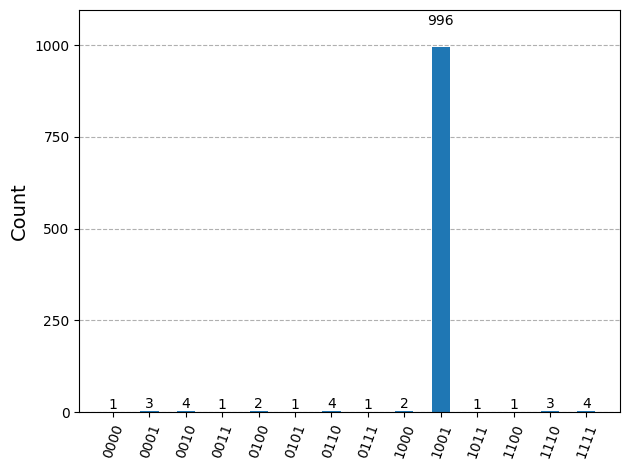

Quantum circuit executed and results obtained.


In [ ]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile

qc.measure(var_qubits, cbits)

simulator = AerSimulator()

# Transpile the circuit to the simulator's basis gates
compiled_circuit = transpile(qc, simulator)

job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(compiled_circuit)

display(plot_histogram(counts))
print("Quantum circuit executed and results obtained.")

### **Step 10: Interpret and Display the Sudoku Solution**

The measurement results (`counts`) show the probability distribution of different assignments to the empty cells. We select the measurement with the highest count as our solution. The binary string from the measurement is then converted back into numbers (1-4) and filled into the `instance` to present the solved Sudoku board. If no empty cells, it means the Sudoku is already solved.

In [ ]:
if num_empty == 0:
    print("Sudoku is already solved:")
    for row in instance:
        print(row)
else:
    # Get the most frequent measurement
    max_count_state = max(counts, key=counts.get)

    # Convert the binary string to the Sudoku solution
    solution_values = []
    state_length = len(max_count_state)
    for i in range(num_empty):
        # Extract 2-bit segments from right to left
        # For i=0, get last two bits; for i=1, get next two bits etc.
        start_idx = state_length - 2 * (i + 1)
        end_idx = state_length - 2 * i
        binary_val = max_count_state[start_idx:end_idx]
        solution_values.append(int(binary_val, 2) + 1)

    # Create the solved Sudoku board
    solved_instance = [row[:] for row in instance] # Deep copy
    for i, (r, c) in enumerate(empty_cells):
        solved_instance[r][c] = solution_values[i]

    print("Solved Sudoku:")
    for row in solved_instance:
        print(row)

Solved Sudoku:
[1, 2, 3, 4]
[3, 4, 1, 2]
[2, 3, 4, 1]
[4, 1, 2, 3]


## **3. Visulization the Quantum Circuit**

### **Circuit Visualization: ASCII Text**

This command generates an ASCII text-based representation of the quantum circuit directly in the console output. It's useful for quickly inspecting the circuit structure without needing a graphical backend.

In [ ]:
print(qc.draw())

           ┌───┐┌───┐     ┌───┐┌───┐          ┌───┐                         »
    var_0: ┤ H ├┤ X ├──■──┤ X ├┤ X ├───────■──┤ X ├───────■─────────■───────»
           ├───┤└───┘  │  ├───┤└───┘       │  ├───┤       │         │       »
    var_1: ┤ H ├───────■──┤ X ├────────────■──┤ X ├───────■─────────┼────■──»
           ├───┤       │  └───┘     ┌───┐  │  └───┘       │  ┌───┐┌─┴─┐  │  »
    var_2: ┤ H ├──■────┼─────────■──┤ X ├──┼─────────■────┼──┤ X ├┤ X ├──┼──»
           ├───┤  │    │  ┌───┐  │  ├───┤  │  ┌───┐  │    │  ├───┤└───┘┌─┴─┐»
    var_3: ┤ H ├──■────┼──┤ X ├──■──┤ X ├──┼──┤ X ├──■────┼──┤ X ├─────┤ X ├»
           ├───┤  │  ┌─┴─┐└───┘  │  └───┘  │  └───┘  │    │  └───┘     └───┘»
 clause_0: ┤ X ├──┼──┤ X ├───────┼─────────┼────■────┼────┼─────────────────»
           ├───┤  │  └───┘       │       ┌─┴─┐  │    │    │                 »
 clause_1: ┤ X ├──┼──────────────┼───────┤ X ├──■────┼────┼─────────────────»
           ├───┤  │              │       └───┘  │    │  ┌─┴─┐   

### **Circuit Visualization: Matplotlib Plot**

This command generates a graphical representation of the quantum circuit using Matplotlib, providing a more detailed and visual layout of the gates and qubits.

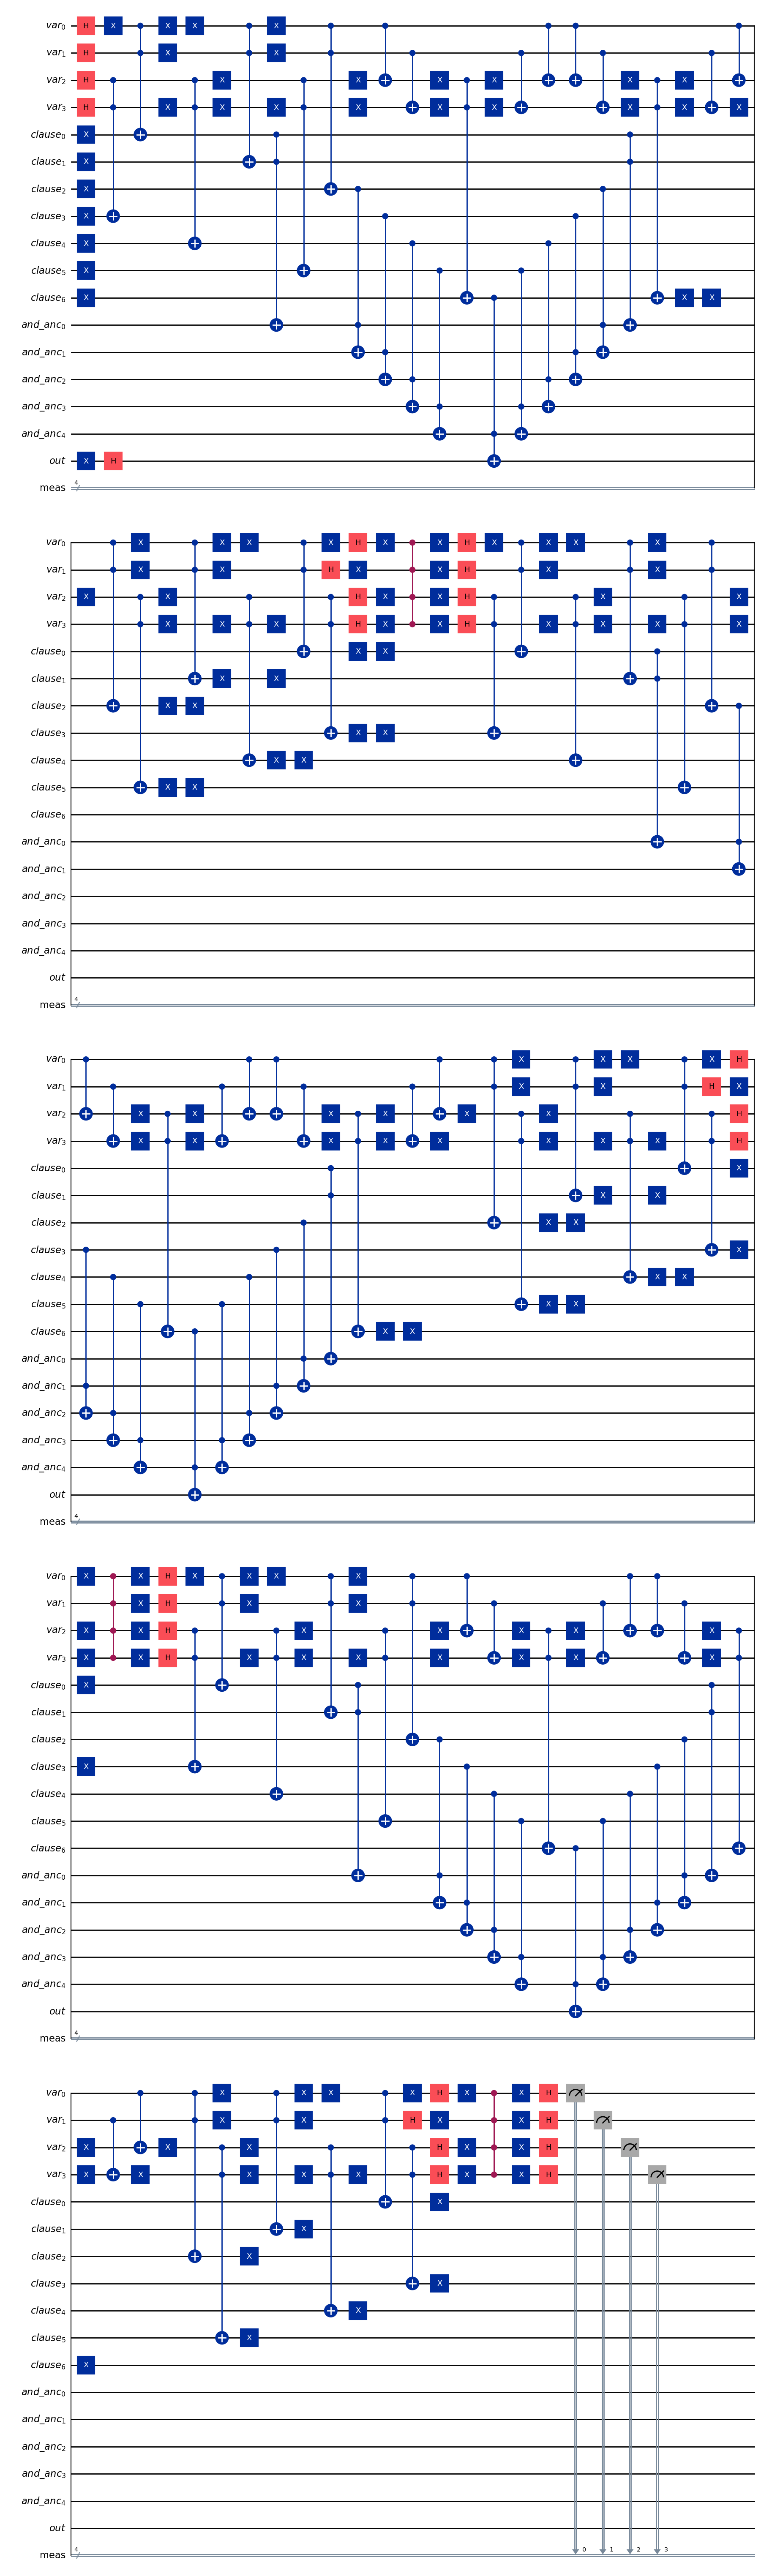

In [ ]:
qc.draw(output='mpl')

## **4. Conclusion**

This notebook successfully demonstrates the application of Grover's algorithm to solve a 4x4 Sudoku puzzle. By encoding the Sudoku constraints into an oracle and iteratively amplifying the amplitudes of valid solutions, the quantum circuit was able to efficiently identify the correct values for the empty cells. This showcases the potential of quantum algorithms for combinatorial problems.

## **5. References**

Czelusta, G., Verma, D. R., & Wanjalkar, G. (2024). Grover's algorithm on two-way quantum computer. arXiv. https://doi.org/10.48550/arxiv.2406.09450.

Jones, D., & Varcoe, B. (2022). A Method for Application of a Quantum Search Algorithm to Classical Databases. arXiv. https://doi.org/10.48550/arxiv.2206.03938.